<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Classification and KNN with NHL data

_Authors: Joseph Nelson (DC)_

---

Below you will practice KNN classification on a dataset of NHL statistics.

You will be predicting the `Rank` of a team from predictor variables of your choice.

In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# web location:
local_csv = '../data/NHL_Data_GA.csv'

### 1. Load the NHL data

In [3]:
# A:
df = pd.read_csv('./data/NHL_Data_GA.csv')

### 2. Perform any required data cleaning. Do some EDA.

In [4]:
# A:
df.head()

,Team,PTS,Rank,TOI,GF,GA,GF60,GA60,GF%,SF,...,FF%,CF,CA,CF60,CA60,CF%,Sh%,Sv%,PDO,PIM
0,Washington10,121,1,2001:52:00,115,73,3.45,2.19,61.2,1112,...,51.3,2138,1935,64.1,58.0,52.5,10.34,93.03,1034,1269
1,Vancouver11,117,1,2056:14:00,94,72,2.74,2.10,56.6,1143,...,53.1,2144,1870,62.6,54.6,53.4,8.22,93.16,1014,985
2,San Jose10,113,1,1929:54:00,90,68,2.80,2.11,57.0,1065,...,50.9,1985,1876,61.7,58.3,51.4,8.45,93.46,1019,1195
3,Chicago10,112,1,2020:23:00,104,83,3.09,2.46,55.6,1186,...,58.1,2093,1572,62.2,46.7,57.1,8.77,90.44,992,966
4,Vancouver12,111,1,2052:02:00,86,74,2.51,2.16,53.8,1078,...,51.0,2085,1880,61.0,55.0,52.6,7.98,93.36,1013,1049


In [5]:
df.shape

(90, 28)

In [6]:
df.dtypes


Team        str
PTS       int64
Rank      int64
TOI         str
GF        int64
GA        int64
GF60    float64
GA60    float64
GF%     float64
SF        int64
SA        int64
SF60    float64
SA60    float64
SF%     float64
FF        int64
FA        int64
FF60    float64
FA60    float64
FF%     float64
CF        int64
CA        int64
CF60    float64
CA60    float64
CF%     float64
Sh%     float64
Sv%     float64
PDO       int64
PIM       int64
dtype: object

In [7]:
df.isnull().sum()

Team    0
PTS     0
Rank    0
TOI     0
GF      0
GA      0
GF60    0
GA60    0
GF%     0
SF      0
SA      0
SF60    0
SA60    0
SF%     0
FF      0
FA      0
FF60    0
FA60    0
FF%     0
CF      0
CA      0
CF60    0
CA60    0
CF%     0
Sh%     0
Sv%     0
PDO     0
PIM     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### 3. Set up the `Rank` variable as your target. How many classes are there?

In [9]:
# A:
X= df.drop(columns = ['Rank'])
y = df['Rank']
print(df['Rank'].nunique())

3


### 4. What is the baseline accuracy?

In [10]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size =0.2,stratify = y, random_state =42)

In [11]:
# A: 
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](3,)","[0.32,0.33,0.35]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](3,)","[1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](27,)","['Team','PTS','TOI',...,'Sv%','PDO','PIM']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,27
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [12]:
dummy_clf.score(X_test,y_test)

0.3333333333333333

In [13]:
most_freq_class = y_train.value_counts().index[0]
most_freq_class

np.int64(3)

In [46]:
baseline_acc=y_test.value_counts()[most_freq_class]/len(y_test)

### 5. Choose 4 features to be your predictor variables and set up your design matrix.

In [15]:
df_num = df.select_dtypes(include = 'number')

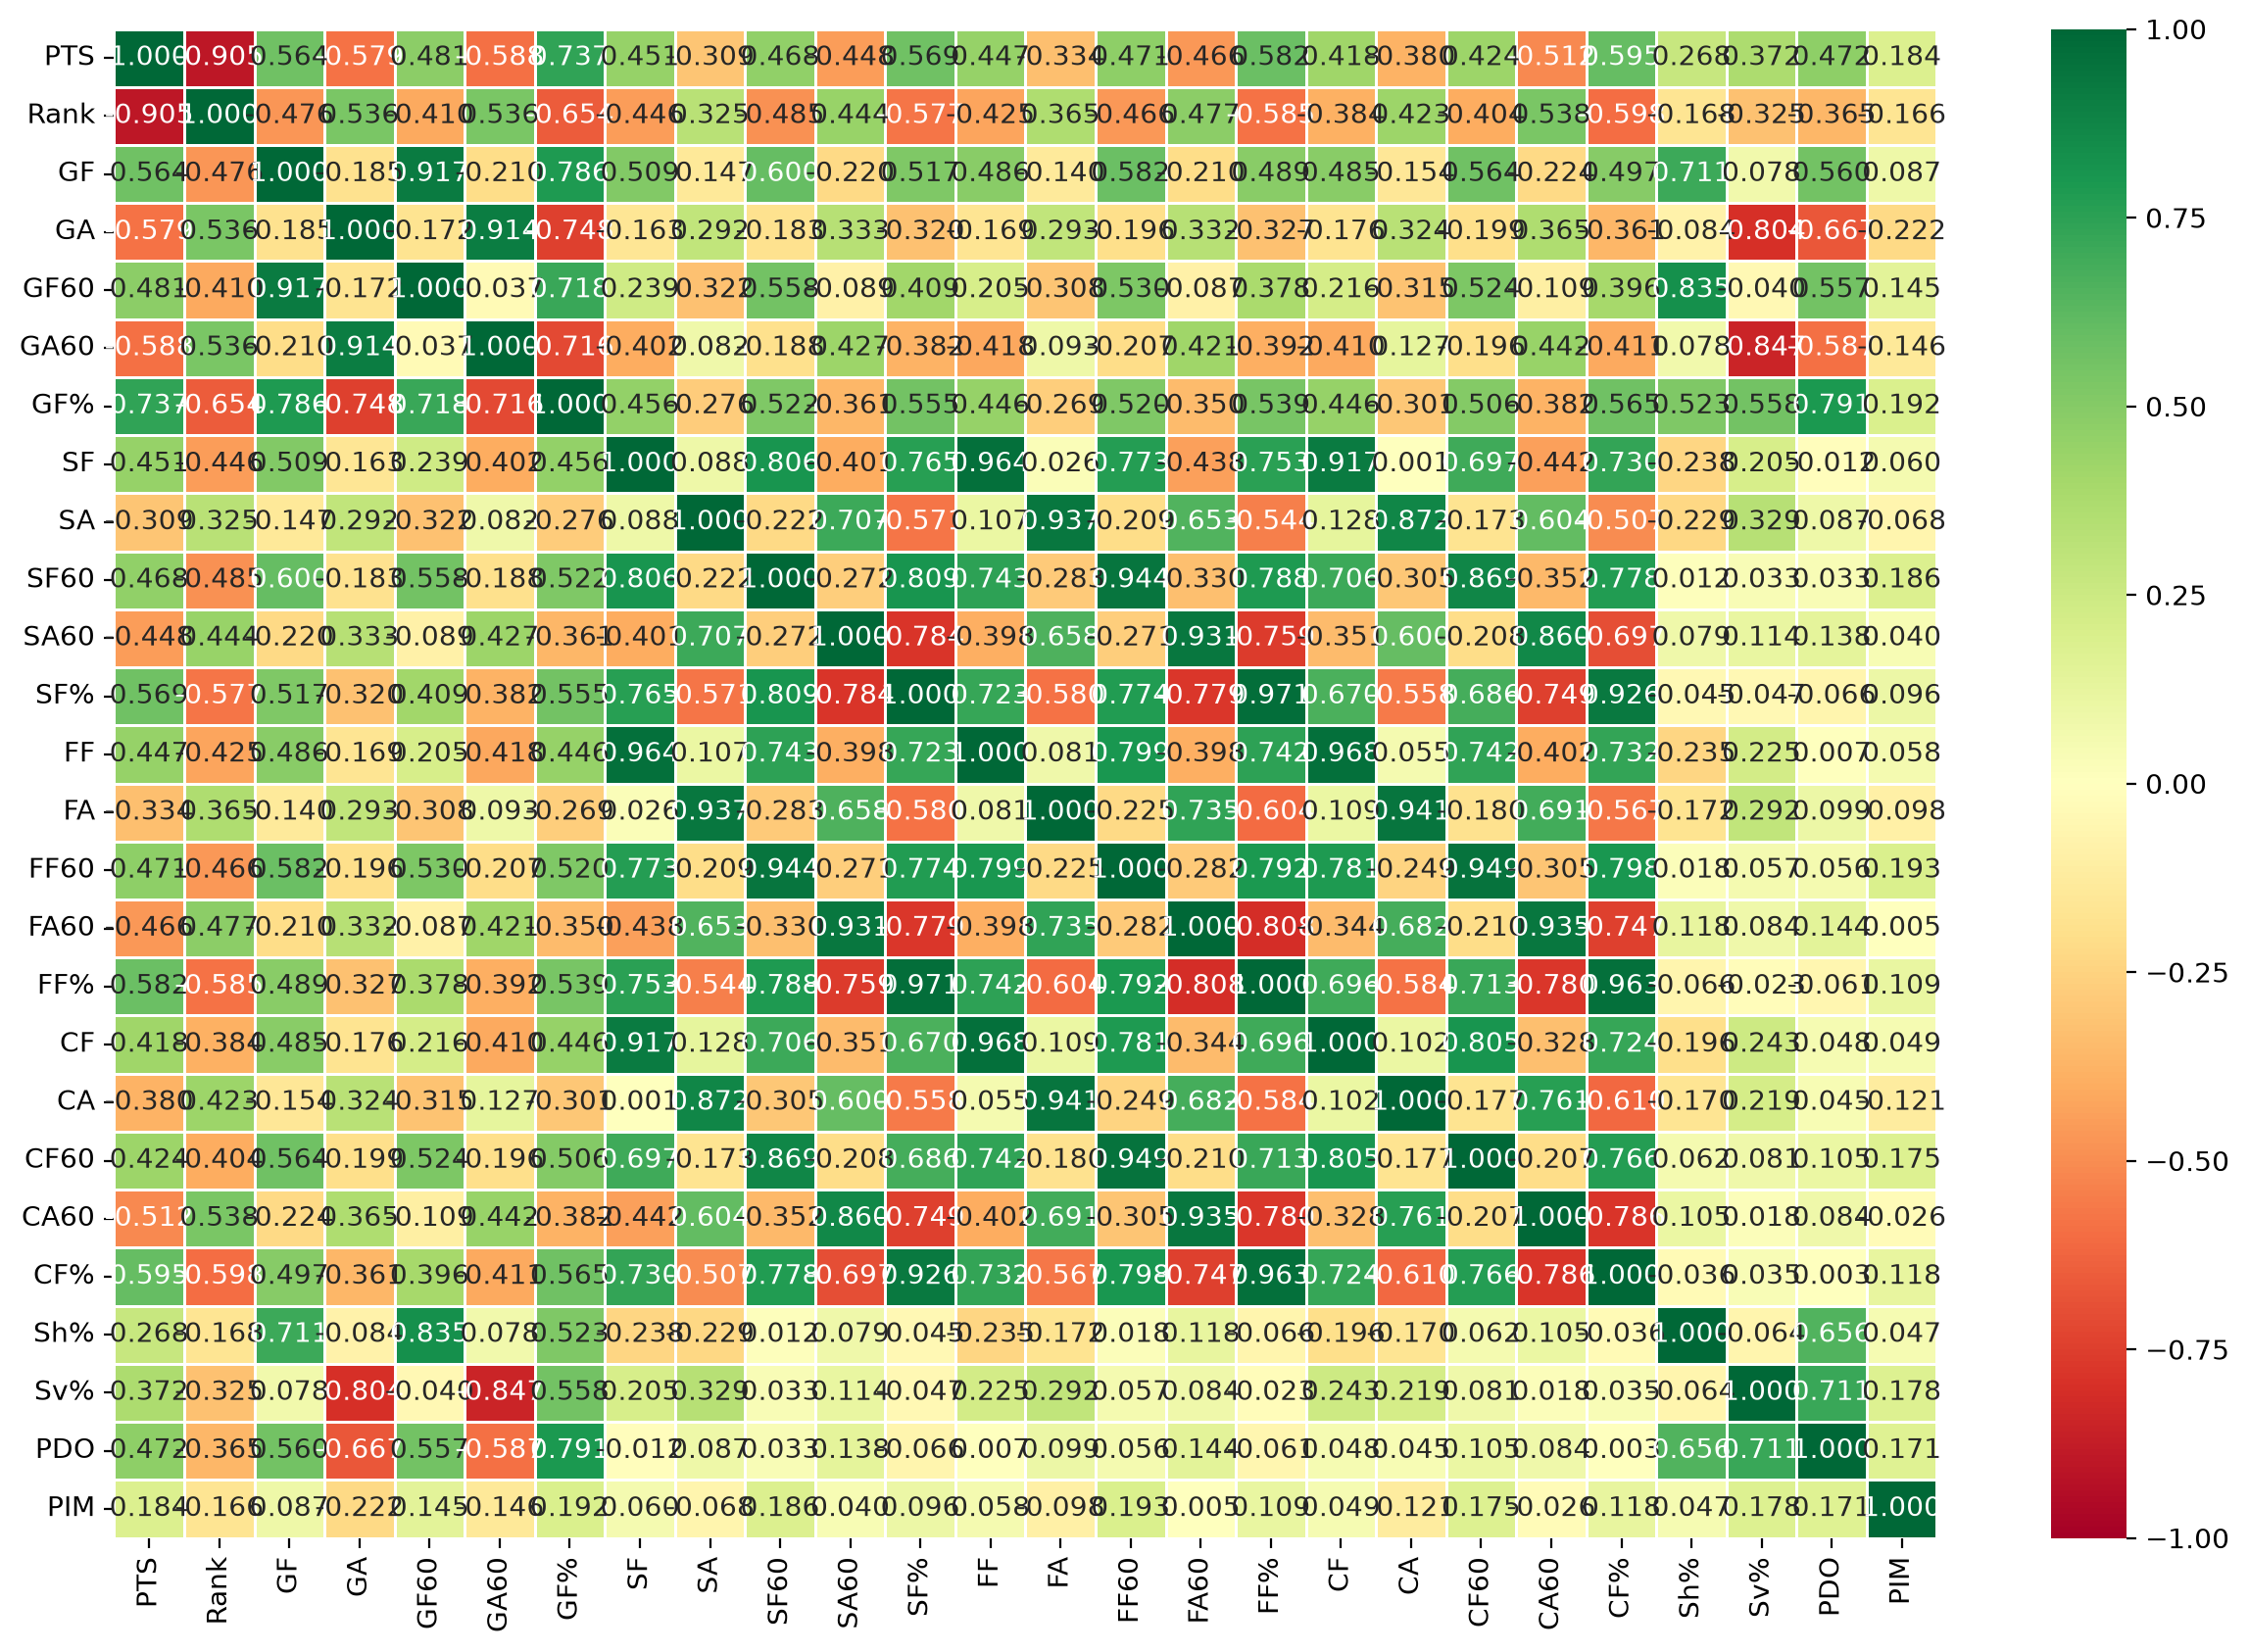

In [16]:
# A:

plt.subplots(figsize=(15, 10))
sns.heatmap(df_num.corr(), annot=True, fmt='.3f', cmap='RdYlGn', linewidth=.5, vmin=-1, vmax=1)
plt.show()

In [22]:
df_num.corr()['Rank'].sort_values(ascending = False)

Rank    1.000000
CA60    0.537879
GA60    0.536279
GA      0.535782
FA60    0.477409
SA60    0.443970
CA      0.423351
FA      0.364666
SA      0.324561
PIM    -0.166454
Sh%    -0.168314
Sv%    -0.324691
PDO    -0.365246
CF     -0.383993
CF60   -0.403508
GF60   -0.409616
FF     -0.425059
SF     -0.446335
FF60   -0.466239
GF     -0.475713
SF60   -0.484563
SF%    -0.577347
FF%    -0.585340
CF%    -0.598466
GF%    -0.653633
PTS    -0.905004
Name: Rank, dtype: float64

In [24]:
features = ['CA60', 'GA60', 'GF%', 'CF%']
X = df_num[features]
y = df['Rank']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### 6. Fit a `KNeighborsClassifier` with 1 neighbor using the target and predictors.

In [26]:
# A:

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 7. Evaluate the accuracy of your model.
- Is it better than baseline?
- Is it legitimate?

In [27]:
# A:
train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

Train accuracy: 1.000
Test accuracy: 0.333


In [28]:
baseline_acc = y_test.value_counts()[most_freq_class] / len(y_test)
print(f"Baseline accuracy: {baseline_acc:.3f}")

Baseline accuracy: 0.333


### 8. Create a 50-50 train-test-split of your target and predictors. Refit the KNN and assess the accuracy.

In [29]:
# A:
X2_train, X2_test, y2_train, y2_test = train_test_split(X,y, test_size =0.5, stratify=y, random_state=42)

In [33]:
knn2 = KNeighborsClassifier(n_neighbors=1)
knn2.fit(X2_train, y2_train)

train_acc2 = knn2.score(X2_train, y2_train)
test_acc2 = knn2.score(X2_test, y2_test)

print(f"Train accuracy: {train_acc2:.3f}")
print(f"Test accuracy: {test_acc2:.3f}")

Train accuracy: 1.000
Test accuracy: 0.533


### 9. Evaluate the test accuracy of a KNN where K == number of rows in the training data.

In [34]:
# A:
k_max_rows = len(X_train)

knn_max_rows = KNeighborsClassifier(n_neighbors=k_max_rows)
knn_max_rows.fit(X_train, y_train)

train_acc_max_rows = knn_max_rows.score(X_train, y_train)
test_acc_max_rows = knn_max_rows.score(X_test, y_test)

print(f"k = {k_max_rows}")
print(f"Train accuracy: {train_acc_max_rows:.3f}")
print(f"Test accuracy: {test_acc_max_rows:.3f}")

k = 72
Train accuracy: 0.347
Test accuracy: 0.333


### 10. Fit the KNN at values of K from 1 to the number of rows in the training data.
- Store the test accuracy in a list.
- Plot the test accuracy vs. the number of neighbors.

In [36]:
# A:
k_range = range(1, len(X_train) + 1)
test_accs = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    acc = knn_k.score(X_test, y_test)
    test_accs.append(acc)

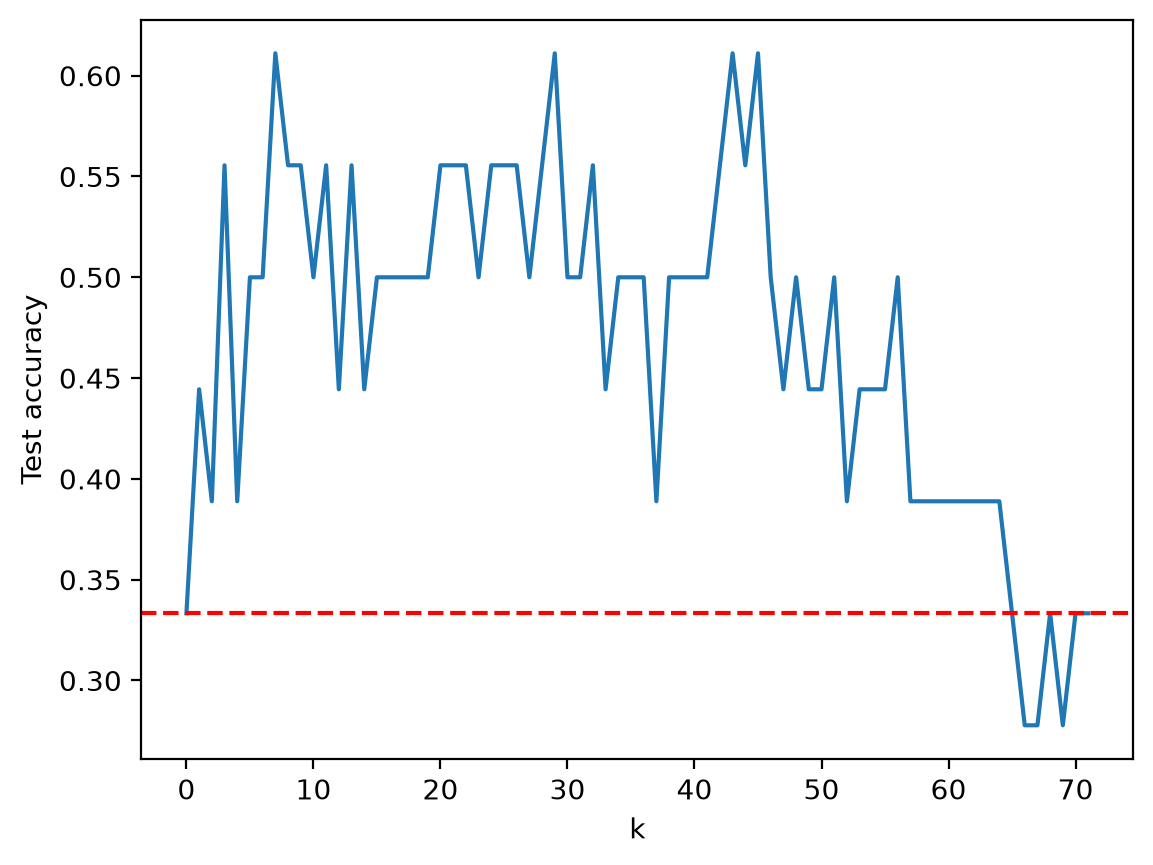

In [47]:
plt.plot(k_range, test_accs)
plt.xlabel('k')
plt.ylabel('Test accuracy')
plt.axhline(baseline_acc, color='red', linestyle='--', label='Baseline accuracy')
plt.show()

### 11. Fit KNN across different values of K and plot the mean cross-validated accuracy with 5 folds.

In [39]:
# A:
from sklearn.model_selection import cross_val_score


C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\model_selection\_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to 0. Details: 
Traceback (most recent call last):
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_scorer.py", line 167, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_scorer.py", line 97, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\utils\_response.py", line 215, in _get_response_values
    y_pred = prediction_method(X)
             ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-pa

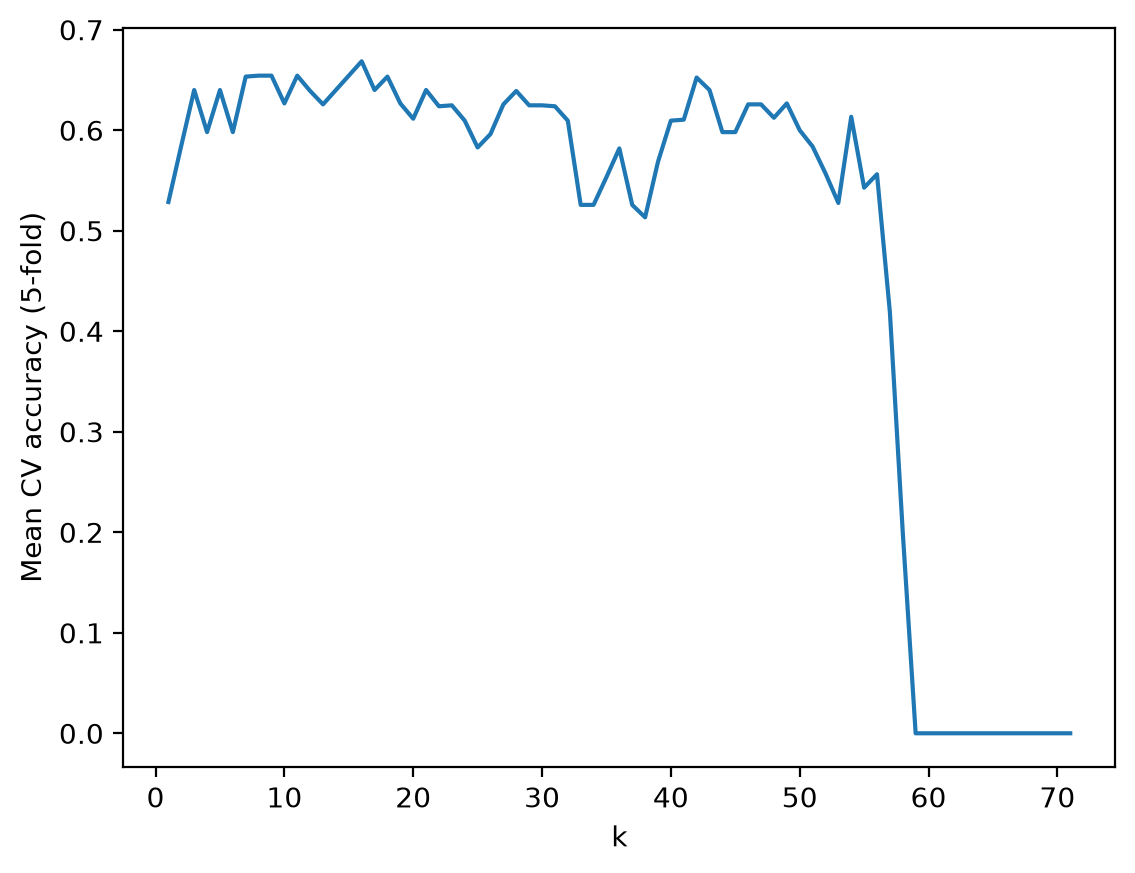

In [51]:
k_range = range(1, len(X_train))
cv_scores = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_k, X_train, y_train, cv=5, scoring='accuracy',error_score=0)
    cv_scores.append(scores.mean())
    
plt.plot(k_range, cv_scores)
plt.xlabel('k')
plt.ylabel('Mean CV accuracy (5-fold)')
plt.show()

### 12. Standardize the predictor matrix and cross-validate across the different K.
- Plot the standardized mean cross-validated accuracy against the unstandardized. Which is better?
- Why?

In [52]:
# A:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\model_selection\_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_scorer.py", line 167, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_scorer.py", line 97, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\utils\_response.py", line 215, in _get_response_values
    y_pred = prediction_method(X)
             ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-

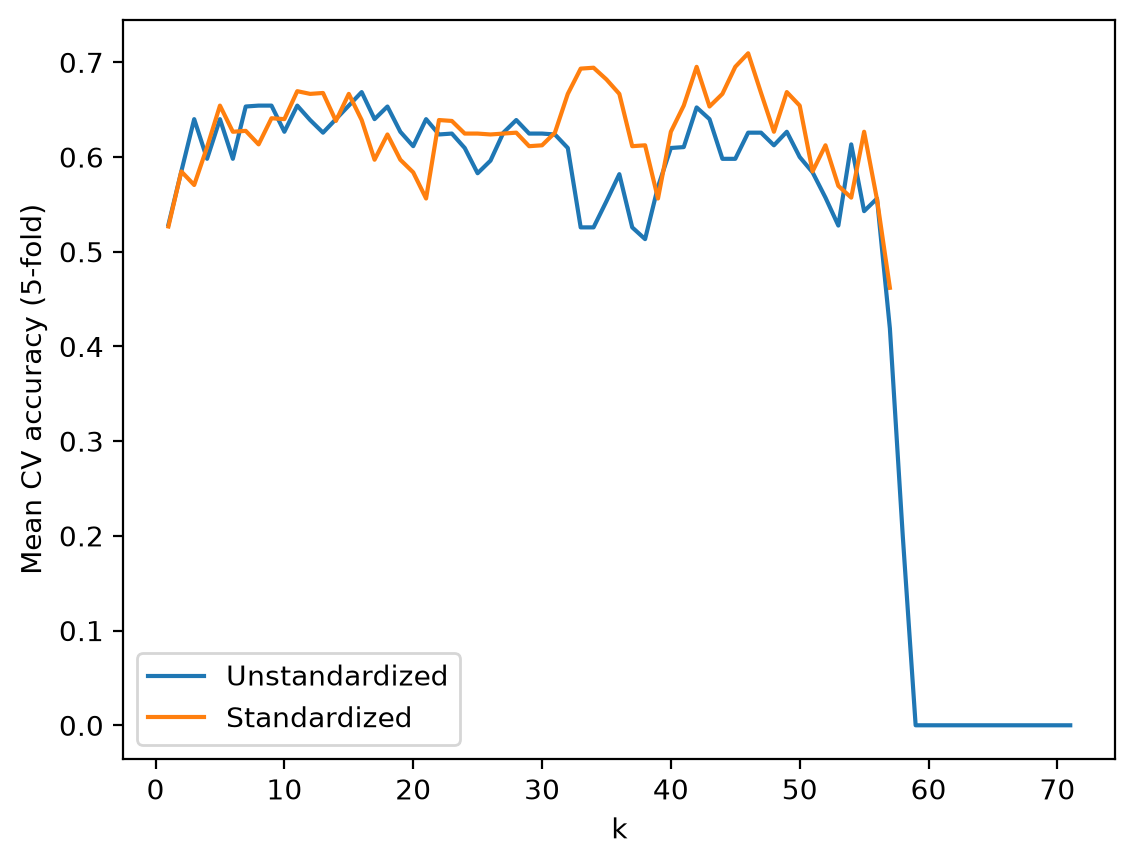

In [53]:
cv_scores_scaled = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_k, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_scaled.append(scores.mean())

plt.plot(k_range, cv_scores, label='Unstandardized')
plt.plot(k_range, cv_scores_scaled, label='Standardized')
plt.xlabel('k')
plt.ylabel('Mean CV accuracy (5-fold)')
plt.legend()
plt.show()

## What was the best 'k'?

Using `GridSearch` & `Pipeline` find the best `k` for the KNN model

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [57]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': list(range(1, len(X_train)  + 1))
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best k:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sk

Best k: {'knn__n_neighbors': 46}
Best CV accuracy: 0.7095238095238094


C:\Users\Dell\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [0.52666667 0.5847619  0.57047619 0.61047619 0.65428571 0.62666667
 0.61333333 0.59904762 0.62761905 0.64       0.66857143 0.65333333
 0.66761905 0.63809524 0.66666667 0.65238095 0.63904762 0.62380952
 0.59714286 0.59714286 0.58380952 0.63904762 0.59809524 0.63904762
 0.63904762 0.65142857 0.63904762 0.61238095 0.61142857 0.63904762
 0.65333333 0.65333333 0.63904762 0.66666667 0.68095238 0.68
 0.66666667 0.59809524 0.59714286 0.62666667 0.66952381 0.69619048
 0.68190476 0.65333333 0.6952381  0.70952381 0.66761905 0.65428571
 0.66857143 0.66857143 0.59809524 0.55714286 0.54190476 0.55714286
 0.62666667 0.5552381  0.46190476        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan]
  warnings.warn(
